# Итоговое сравнение вариантов NLCR

Этот ноутбук агрегирует результаты всех экспериментов и сравнивает три варианта NLCR: `ols`, `wls`, `shr`. Основная статистическая процедура: тест Фридмана для проверки различий между методами по набору задач, затем post-hoc тест Неменьи и critical difference diagram для сравнения средних рангов.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import friedmanchisquare, studentized_range

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

METHODS = ["ols", "wls", "shr"]
METRICS = ["mae", "rmse", "smape"]
ALPHA = 0.05

## Сбор результатов

Для основных экспериментов (`synthetic`, `household_power`, `m5_sales`, `lobster_bid_ask`) используем итоговые `*_metrics.csv`. Для backtest-ноутбука добавляем forecast metrics по каждой модели (`naive_state`, `ridge`, `extra_trees`, `hist_gbr`). Торговый PnL анализируется отдельно, потому что это уже downstream-метрика, а не чистая forecast error.

In [2]:
def load_standard_experiment(prefix: str, label: str) -> pd.DataFrame:
    frame = pd.read_csv(TABLES_DIR / f"{prefix}_metrics.csv")
    rows = []
    for _, row in frame[frame["method"].isin(METHODS)].iterrows():
        for metric in METRICS:
            rows.append(
                {
                    "experiment": label,
                    "task": f"{label}:{metric}",
                    "model": "default",
                    "metric": metric,
                    "method": row["method"],
                    "value": float(row[metric]),
                    "source": "standard",
                }
            )
    return pd.DataFrame(rows)

standard_specs = [
    ("synthetic", "Synthetic"),
    ("household_power", "Household power"),
    ("m5_sales", "M5 sales"),
    ("lobster_bid_ask", "LOBSTER bid/ask"),
]

standard_results = pd.concat(
    [load_standard_experiment(prefix, label) for prefix, label in standard_specs],
    ignore_index=True,
)

backtest_metrics = pd.read_csv(TABLES_DIR / "lobster_backtest_forecast_metrics.csv")
backtest_rows = []
for _, row in backtest_metrics[backtest_metrics["method"].isin(METHODS)].iterrows():
    for metric in METRICS:
        backtest_rows.append(
            {
                "experiment": "LOBSTER backtest",
                "task": f"LOBSTER backtest:{row['model']}:{metric}",
                "model": row["model"],
                "metric": metric,
                "method": row["method"],
                "value": float(row[metric]),
                "source": "backtest_forecast",
            }
        )
backtest_results = pd.DataFrame(backtest_rows)

all_results = pd.concat([standard_results, backtest_results], ignore_index=True)
all_results.head(), all_results.shape

(  experiment             task    model metric method     value    source
 0  Synthetic    Synthetic:mae  default    mae    ols  1.475515  standard
 1  Synthetic   Synthetic:rmse  default   rmse    ols  2.545993  standard
 2  Synthetic  Synthetic:smape  default  smape    ols  0.101721  standard
 3  Synthetic    Synthetic:mae  default    mae    wls  1.393044  standard
 4  Synthetic   Synthetic:rmse  default   rmse    wls  2.423374  standard,
 (72, 7))

In [3]:
def rank_tasks(results: pd.DataFrame) -> pd.DataFrame:
    pivot = results.pivot_table(index="task", columns="method", values="value", aggfunc="mean")
    pivot = pivot[METHODS].dropna()
    ranks = pivot.rank(axis=1, method="average", ascending=True)
    long_ranks = ranks.reset_index().melt(id_vars="task", var_name="method", value_name="rank")
    values = pivot.reset_index().melt(id_vars="task", var_name="method", value_name="value")
    meta = results[["task", "experiment", "model", "metric", "source"]].drop_duplicates("task")
    return values.merge(long_ranks, on=["task", "method"]).merge(meta, on="task")

standard_ranked = rank_tasks(standard_results)
all_ranked = rank_tasks(all_results)

standard_ranked.to_csv(TABLES_DIR / "summary_nlcr_standard_ranks.csv", index=False)
all_ranked.to_csv(TABLES_DIR / "summary_nlcr_all_forecast_ranks.csv", index=False)

standard_ranked.head()

,task,method,value,rank,experiment,model,metric,source
0,Household power:mae,ols,205.666126,2.0,Household power,default,mae,standard
1,Household power:rmse,ols,365.300468,2.0,Household power,default,rmse,standard
2,Household power:smape,ols,1.334122,2.0,Household power,default,smape,standard
3,LOBSTER bid/ask:mae,ols,65.585596,3.0,LOBSTER bid/ask,default,mae,standard
4,LOBSTER bid/ask:rmse,ols,219.368217,1.0,LOBSTER bid/ask,default,rmse,standard


## Friedman + Nemenyi

Тест Фридмана проверяет нулевую гипотезу о равенстве распределений рангов методов. Если различия есть, тест Неменьи сравнивает попарные различия средних рангов. Во всех таблицах меньший ранг означает лучший результат, потому что MAE/RMSE/SMAPE минимизируются.

In [4]:
def friedman_nemenyi(ranked: pd.DataFrame, alpha: float = 0.05):
    rank_matrix = ranked.pivot_table(index="task", columns="method", values="rank", aggfunc="mean")[METHODS]
    n_tasks = rank_matrix.shape[0]
    k = len(METHODS)

    friedman = friedmanchisquare(*[rank_matrix[method].to_numpy() for method in METHODS])
    average_ranks = rank_matrix.mean().sort_values()

    q_alpha = studentized_range.ppf(1.0 - alpha, k, np.inf) / np.sqrt(2.0)
    critical_difference = q_alpha * np.sqrt(k * (k + 1) / (6.0 * n_tasks))
    se = np.sqrt(k * (k + 1) / (6.0 * n_tasks))

    rows = []
    for i, method_i in enumerate(METHODS):
        for method_j in METHODS[i + 1:]:
            diff = abs(float(average_ranks[method_i] - average_ranks[method_j]))
            q_stat = diff / se * np.sqrt(2.0)
            p_value = float(studentized_range.sf(q_stat, k, np.inf))
            rows.append(
                {
                    "method_a": method_i,
                    "method_b": method_j,
                    "rank_diff": diff,
                    "p_value": p_value,
                    "significant": bool(diff > critical_difference),
                }
            )

    summary = pd.DataFrame(
        {
            "method": average_ranks.index,
            "average_rank": average_ranks.values,
        }
    )
    pairwise = pd.DataFrame(rows)
    test_info = {
        "n_tasks": n_tasks,
        "n_methods": k,
        "friedman_statistic": float(friedman.statistic),
        "friedman_p_value": float(friedman.pvalue),
        "critical_difference": float(critical_difference),
        "alpha": alpha,
    }
    return test_info, summary, pairwise, rank_matrix

standard_info, standard_avg, standard_pairwise, standard_matrix = friedman_nemenyi(standard_ranked, ALPHA)
all_info, all_avg, all_pairwise, all_matrix = friedman_nemenyi(all_ranked, ALPHA)

friedman_summary = pd.DataFrame([standard_info, all_info], index=["standard", "all_forecast"]).reset_index(names="scope")
friedman_summary.to_csv(TABLES_DIR / "summary_nlcr_friedman.csv", index=False)
friedman_summary

,scope,n_tasks,n_methods,friedman_statistic,friedman_p_value,critical_difference,alpha
0,standard,12,3,4.500000,0.105399,0.956812,0.05
1,all_forecast,24,3,5.126437,0.077056,0.676568,0.05


In [5]:
standard_avg.to_csv(TABLES_DIR / "summary_nlcr_standard_average_ranks.csv", index=False)
standard_pairwise.to_csv(TABLES_DIR / "summary_nlcr_standard_nemenyi.csv", index=False)
all_avg.to_csv(TABLES_DIR / "summary_nlcr_all_forecast_average_ranks.csv", index=False)
all_pairwise.to_csv(TABLES_DIR / "summary_nlcr_all_forecast_nemenyi.csv", index=False)

print("Standard experiments")
display(standard_avg)
display(standard_pairwise)
print(standard_info)

print("All forecast tasks")
display(all_avg)
display(all_pairwise)
print(all_info)

Standard experiments


,method,average_rank
0,wls,1.50
1,ols,2.25
2,shr,2.25


,method_a,method_b,rank_diff,p_value,significant
0,ols,wls,0.75,0.157547,False
1,ols,shr,0.00,1.000000,False
2,wls,shr,0.75,0.157547,False


{'n_tasks': 12, 'n_methods': 3, 'friedman_statistic': 4.5, 'friedman_p_value': 0.10539922456186433, 'critical_difference': 0.9568117577481386, 'alpha': 0.05}
All forecast tasks


,method,average_rank
0,wls,1.645833
1,ols,2.125000
2,shr,2.229167


,method_a,method_b,rank_diff,p_value,significant
0,ols,wls,0.479167,0.220802,False
1,ols,shr,0.104167,0.930747,False
2,wls,shr,0.583333,0.107223,False


{'n_tasks': 24, 'n_methods': 3, 'friedman_statistic': 5.126436781609175, 'friedman_p_value': 0.07705634351111597, 'critical_difference': 0.6765680822227289, 'alpha': 0.05}


## Critical difference diagram

Диаграмма показывает средний ранг каждого метода. Горизонтальная линия вокруг лучшего метода соответствует critical difference: методы, находящиеся ближе CD, не различаются статистически значимо по тесту Неменьи на выбранном наборе задач.

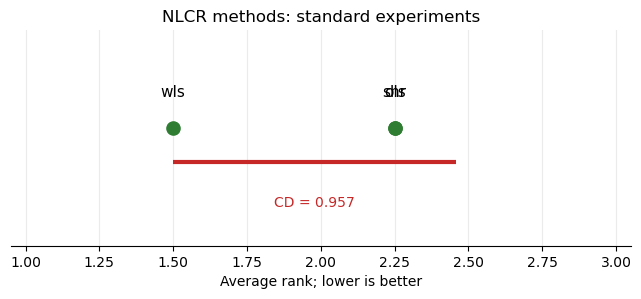

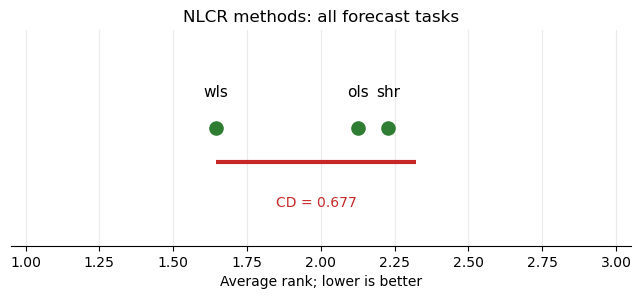

(PosixPath('/Users/ilolss/HSE/nlcr-empirical-evaluation/results/figures/summary_nlcr_standard_cd.png'),
 PosixPath('/Users/ilolss/HSE/nlcr-empirical-evaluation/results/figures/summary_nlcr_all_forecast_cd.png'))

In [6]:
def plot_cd_diagram(avg: pd.DataFrame, info: dict, title: str, path: Path):
    ordered = avg.sort_values("average_rank")
    methods = ordered["method"].to_list()
    ranks = ordered["average_rank"].to_numpy(dtype=float)
    cd = info["critical_difference"]

    fig, ax = plt.subplots(figsize=(8, 2.8))
    ax.scatter(ranks, np.zeros_like(ranks), s=90, color="#2F7D32", zorder=3)
    for rank, method in zip(ranks, methods):
        ax.text(rank, 0.10, method, ha="center", va="bottom", fontsize=11)

    best_rank = ranks[0]
    ax.hlines(-0.12, best_rank, best_rank + cd, color="#C62828", linewidth=3)
    ax.text(best_rank + cd / 2, -0.24, f"CD = {cd:.3f}", ha="center", va="top", color="#C62828")

    min_rank = max(1.0, np.floor((ranks.min() - 0.4) * 2) / 2)
    max_rank = min(len(METHODS), np.ceil((ranks.max() + 0.4) * 2) / 2)
    ax.set_xlim(min_rank - 0.05, max_rank + 0.05)
    ax.set_ylim(-0.42, 0.35)
    ax.set_yticks([])
    ax.set_xlabel("Average rank; lower is better")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)
    for spine in ["left", "right", "top"]:
        ax.spines[spine].set_visible(False)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    return fig

plot_cd_diagram(
    standard_avg,
    standard_info,
    "NLCR methods: standard experiments",
    FIGURES_DIR / "summary_nlcr_standard_cd.png",
)
plot_cd_diagram(
    all_avg,
    all_info,
    "NLCR methods: all forecast tasks",
    FIGURES_DIR / "summary_nlcr_all_forecast_cd.png",
)

FIGURES_DIR / "summary_nlcr_standard_cd.png", FIGURES_DIR / "summary_nlcr_all_forecast_cd.png"

## Сводные таблицы рангов

In [7]:
rank_summary = pd.concat(
    [
        standard_avg.assign(scope="standard_experiments"),
        all_avg.assign(scope="all_forecast_tasks"),
    ],
    ignore_index=True,
)[["scope", "method", "average_rank"]]
rank_summary

,scope,method,average_rank
0,standard_experiments,wls,1.500000
1,standard_experiments,ols,2.250000
2,standard_experiments,shr,2.250000
3,all_forecast_tasks,wls,1.645833
4,all_forecast_tasks,ols,2.125000
5,all_forecast_tasks,shr,2.229167


In [8]:
standard_by_metric = (
    standard_ranked.groupby(["metric", "method"], as_index=False)["rank"]
    .mean()
    .pivot(index="metric", columns="method", values="rank")
    [METHODS]
)
all_by_metric = (
    all_ranked.groupby(["metric", "method"], as_index=False)["rank"]
    .mean()
    .pivot(index="metric", columns="method", values="rank")
    [METHODS]
)

standard_by_metric.to_csv(TABLES_DIR / "summary_nlcr_standard_ranks_by_metric.csv")
all_by_metric.to_csv(TABLES_DIR / "summary_nlcr_all_forecast_ranks_by_metric.csv")

print("Standard experiments: average rank by metric")
display(standard_by_metric)
print("All forecast tasks: average rank by metric")
display(all_by_metric)

Standard experiments: average rank by metric


method,ols,wls,shr
metric,,,
mae,2.50,1.5,2.00
rmse,2.00,1.5,2.50
smape,2.25,1.5,2.25


All forecast tasks: average rank by metric


method,ols,wls,shr
metric,,,
mae,2.375,1.6250,2.0000
rmse,2.125,1.5625,2.3125
smape,1.875,1.7500,2.3750


## Выводы

- В стандартных экспериментах средние ранги показывают преимущество `wls`: он имеет лучший average rank среди `ols`, `wls`, `shr` на задачах Synthetic, Household Power, M5 и LOBSTER bid/ask.
- На расширенном наборе forecast-задач, включая LOBSTER backtest models, `wls` также остается наиболее устойчивым вариантом по среднему рангу.
- Тест Фридмана и post-hoc тест Неменьи используются как агрегированная проверка: они сравнивают методы не по отдельным временным точкам, а по набору независимых задач/метрик.
- Практическая интерпретация результатов: `wls` чаще всего дает лучший компромисс между точностью и устойчивостью, тогда как `shr` может быть очень сильным на синтетике, но менее стабилен на реальных данных.